In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

In [ ]:
data = fetch_20newsgroups(subset='all')

X = data.data
y = data.target
target_names = data.target_names

print("Number of samples:", len(X))
print("Number of classes:", len(target_names))

Number of samples: 18846
Number of classes: 20


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.7
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
report = classification_report(y_test, y_pred, target_names=target_names)
print(report)

                          precision    recall  f1-score   support

             alt.atheism       0.89      0.90      0.90       151
           comp.graphics       0.79      0.87      0.83       202
 comp.os.ms-windows.misc       0.83      0.83      0.83       195
comp.sys.ibm.pc.hardware       0.72      0.76      0.74       183
   comp.sys.mac.hardware       0.90      0.86      0.88       205
          comp.windows.x       0.90      0.85      0.87       215
            misc.forsale       0.84      0.83      0.83       193
               rec.autos       0.91      0.94      0.92       196
         rec.motorcycles       0.97      0.93      0.95       168
      rec.sport.baseball       0.97      0.97      0.97       211
        rec.sport.hockey       0.96      0.97      0.97       198
               sci.crypt       0.98      0.95      0.96       201
         sci.electronics       0.87      0.87      0.87       202
                 sci.med       0.95      0.95      0.95       194
         

In [ ]:
f1_scores = f1_score(y_test, y_pred, average=None)

for i, score in enumerate(f1_scores):
    print(f"{target_names[i]}: {score:.2f}")

alt.atheism: 0.90
comp.graphics: 0.83
comp.os.ms-windows.misc: 0.83
comp.sys.ibm.pc.hardware: 0.74
comp.sys.mac.hardware: 0.88
comp.windows.x: 0.87
misc.forsale: 0.83
rec.autos: 0.92
rec.motorcycles: 0.95
rec.sport.baseball: 0.97
rec.sport.hockey: 0.97
sci.crypt: 0.96
sci.electronics: 0.87
sci.med: 0.95
sci.space: 0.94
soc.religion.christian: 0.94
talk.politics.guns: 0.93
talk.politics.mideast: 0.99
talk.politics.misc: 0.89
talk.religion.misc: 0.80


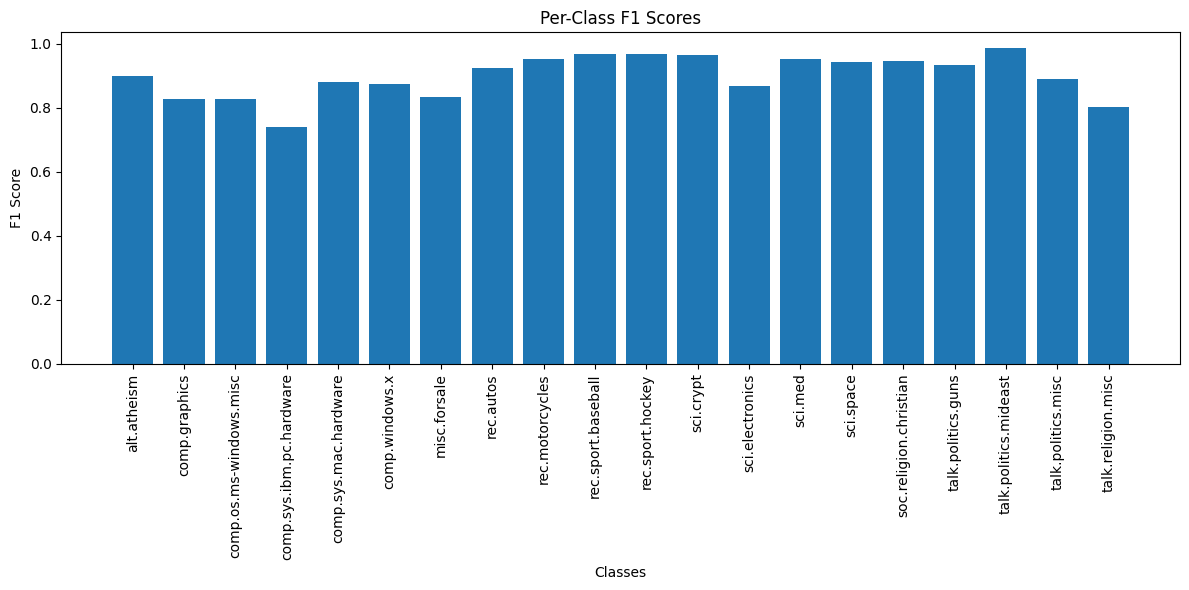

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(target_names, f1_scores)

plt.xticks(rotation=90)
plt.xlabel("Classes")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Scores")

plt.tight_layout()
plt.show()